# POS Tagging & Named Entity Recognition (NER)
## Proyek: Analisis Sentimen & Dampak TikTok Shop terhadap UMKM Indonesia

Notebook ini melanjutkan pipeline NLP setelah tahap **Preprocessing** (tokenisasi, stopword removal, stemming Sastrawi).


---
**Pipeline lengkap:**
1. ✅ Scraping → 2. ✅ Preprocessing → 3. ✅ TF-IDF → **4. 🔄 POS & NER (tahap ini)**


## Cell 1: Install & Import Dependencies

In [4]:

%pip install transformers torch --quiet

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import json, os, ast

# Hugging Face specific imports
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

sns.set_style("whitegrid")
os.makedirs("/content/data", exist_ok=True)
os.makedirs("/content/figures", exist_ok=True)

print("✅ Semua library berhasil diimport.")

✅ Semua library berhasil diimport.


In [5]:
# Load CSV hasil preprocessing
csv_path = "/content/scraped_articles_preprocessed.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(
        f"File tidak ditemukan: {csv_path}\n"
        "Upload file 'scraped_articles_preprocessed.csv' ke /content/ terlebih dahulu."
    )

df = pd.read_csv(csv_path, low_memory=False)
print(f"✅ Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")
print("Kolom tersedia:", df.columns.tolist())
display(df.head(3))

# ─── Pilih kolom teks terbaik untuk analisis ───
# Prioritas: stemming_cleaned > stopword_removed > content_cleaned
text_col = None
for cand in ["stemming_cleaned", "stopword_removed", "content_cleaned"]:
    if cand in df.columns and df[cand].notna().sum() > 0:
        text_col = cand
        break

if text_col is None:
    raise ValueError("Tidak ada kolom teks yang valid. Periksa hasil preprocessing.")

print(f"\n📌 Menggunakan kolom teks: '{text_col}'")

# Konversi kolom list (jika tersimpan sebagai string) ke string teks
def col_to_text(val):
    if isinstance(val, list):
        return " ".join(val)
    if isinstance(val, str):
        # coba parse sebagai list Python
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                return " ".join(parsed)
        except:
            pass
        return val
    return ""

df["text_for_nlp"] = df[text_col].apply(col_to_text)
print(f"\n📄 Contoh teks pertama:\n{df['text_for_nlp'].iloc[0][:300]}...")

✅ Dataset berhasil dimuat: 804 baris, 13 kolom
Kolom tersedia: ['title', 'source', 'link asli', 'published', 'content', 'category', 'sentimen', 'scrape_status', 'content_cleaned', 'tokenization', 'stopword_removed', 'stemming_output', 'stemming_cleaned']


,title,source,link asli,published,content,category,sentimen,scrape_status,content_cleaned,tokenization,stopword_removed,stemming_output,stemming_cleaned
0,TikTok raises minimum user age in Indonesia fo...,ANTARA News Bali,https://bali.antaranews.com/berita/403417/tikt...,2026-04-14 11:19:15,Jakarta (ANTARA) -\nSocial media giant TikTok ...,Regulasi,Netral,Success,social media giant tiktok announced that it ha...,"['social', 'media', 'giant', 'tiktok', 'announ...","['social', 'media', 'giant', 'tiktok', 'announ...","['social', 'media', 'giant', 'tiktok', 'announ...","['social', 'media', 'giant', 'tiktok', 'that',..."
1,TikTok Indonesia Resmi Umumkan Tutup Fitur Tik...,Jawa Pos,https://www.jawapos.com/aplikasi/2310040011/ti...,2026-04-12 16:57:43,Fitur TikTok Shop resmi ditutup hari ini./\nJa...,Isu,Negatif,Success,tiktokshop mulai hari ini rabu tepatnya pada p...,"['tiktokshop', 'mulai', 'hari', 'ini', 'rabu',...","['tiktokshop', 'rabu', 'tepatnya', 'wib', 'res...","['tiktokshop', 'rabu', 'tepat', 'wib', 'resmi'...","['tiktokshop', 'rabu', 'tepat', 'wib', 'resmi'..."
2,LIVE Tokopedia–TikTok Shop Ditonton 38 Miliar ...,SWA.co.id,https://swa.co.id/read/471326/live-tokopediati...,2026-04-12 14:45:00,Kementerian Perdagangan mencatat nilai penjual...,Bisnis,Positif,Success,kementerian perdagangan mencatat nilai penjual...,"['kementerian', 'perdagangan', 'mencatat', 'ni...","['kementerian', 'perdagangan', 'mencatat', 'ni...","['menteri', 'dagang', 'catat', 'nilai', 'jual'...","['menteri', 'dagang', 'catat', 'nilai', 'jual'..."



📌 Menggunakan kolom teks: 'stemming_cleaned'

📄 Contoh teks pertama:
social media giant tiktok that it has the minimum age to access its platform in indonesia to comply with the country s new regulation on protection in digital platforms as stated on tiktok s official website and confirmed on the new policy with government regulation no of regarding electronic system...


## Cell 3: Load Hugging Face Models for POS and NER

model berbasis Transformer dari Hugging Face yang lebih spesifik dan unggul untuk Bahasa Indonesia. Kami akan menggunakan:

*   **NER**: `cahya/bert-base-indonesian-NER` (model IndoBERT yang dilatih khusus untuk Named Entity Recognition Bahasa Indonesia).
*   **POS Tagging**: `w11wo/indonesian-roberta-base-posp` (model RoBERTa yang di-fine-tune untuk Part-of-Speech tagging Bahasa Indonesia).

Model ini akan memberikan hasil yang lebih akurat dan relevan untuk konteks Bahasa Indonesia

In [6]:
# Load Tokenizer and Model for NER
ner_model_name = "cahya/bert-base-indonesian-NER"
ner_tokenizer = AutoTokenizer.from_pretrained(ner_model_name)
ner_model = AutoModelForTokenClassification.from_pretrained(ner_model_name)
ner_pipeline = pipeline("ner", model=ner_model, tokenizer=ner_tokenizer, aggregation_strategy="simple",
                        # truncation=True,
                        # max_length=512,
                        device=0)
print(f"✅ Model NER ({ner_model_name}) berhasil dimuat.")

# Load Tokenizer and Model for POS Tagging
# Corrected model name for POS tagging to a publicly available one
pos_model_name = "w11wo/indonesian-roberta-base-posp-tagger"
pos_tokenizer = AutoTokenizer.from_pretrained(pos_model_name)
pos_model = AutoModelForTokenClassification.from_pretrained(pos_model_name)
# Using 'ner' pipeline type as it's token classification
pos_pipeline = pipeline(
    "token-classification",
    model=pos_model,
    tokenizer=pos_tokenizer,
    aggregation_strategy="simple",
    # truncation=True,
    # max_length=512,
    device=0
)
print(f"✅ Model POS ({pos_model_name}) berhasil dimuat.")

# Prepare texts for processing (from previous Cell 2)
# This line will cause a NameError if df and texts are not defined, which happens if Cell 2 failed or not executed.
texts = df["text_for_nlp"].fillna("").astype(str).tolist()
print(f"\n📊 Total dokumen yang akan diproses: {len(texts)}")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Model POS (w11wo/indonesian-roberta-base-posp-tagger) berhasil dimuat.

📊 Total dokumen yang akan diproses: 804


## Cell 4: POS Tagging — Distribusi Agregat dengan IndoBERT

 Kami akan menggunakan model `w11wo/indonesian-roberta-base-posp` untuk mendapatkan POS tag dari setiap token dalam dokumen. Kemudian, kami akan menghitung distribusi agregat dari semua POS tag untuk memahami komposisi gramatikal teks secara keseluruhan.

⏳ Proses POS tagging dengan IndoBERT...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ Disimpan → /content/data/pos_distribution_indobert.csv


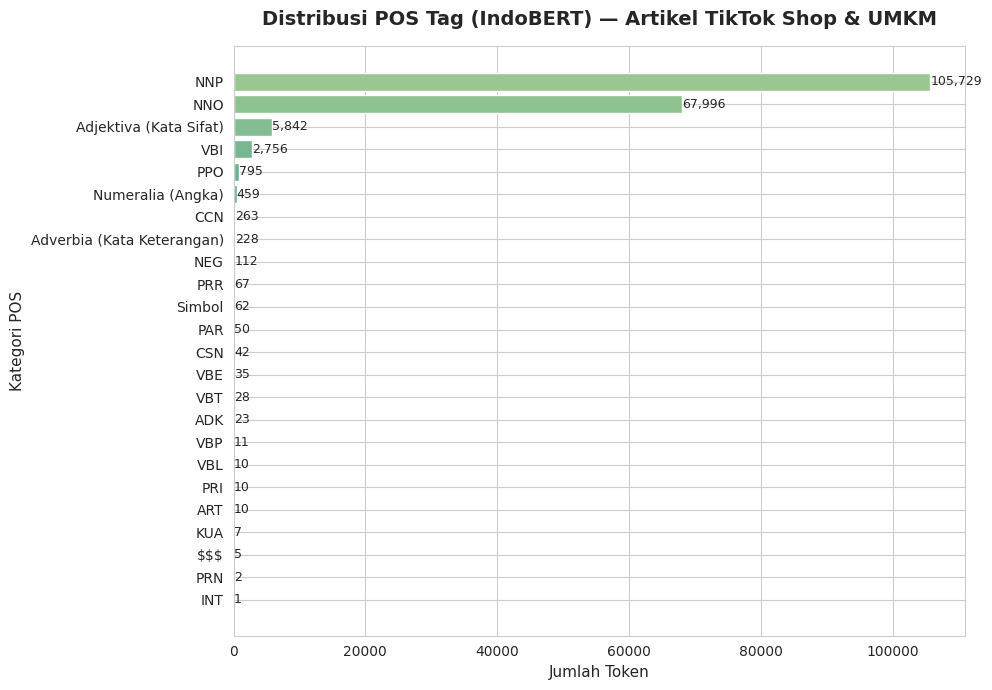

✅ Plot disimpan → /content/figures/pos_distribution_indobert.png


,POS,label_id,count
0,NNP,NNP,105729
1,NNO,NNO,67996
2,ADJ,Adjektiva (Kata Sifat),5842
3,VBI,VBI,2756
4,PPO,PPO,795
5,NUM,Numeralia (Angka),459
6,CCN,CCN,263
7,ADV,Adverbia (Kata Keterangan),228
8,NEG,NEG,112
9,PRR,PRR,67


In [7]:
# --- POS Tagging: Agregasi di seluruh dokumen ---

pos_counts = Counter()
all_tokens_pos = []

print("⏳ Proses POS tagging dengan IndoBERT...")
# Process texts in batches
batch_size = 8 # Adjust batch size based on GPU memory
max_seq_length = 512 # Max sequence length for the model

for i in range(0, len(texts), batch_size):
    batch_texts = texts[i:i + batch_size]
    # Manually truncate texts to max_seq_length * 4 characters (rough estimate)
    # to avoid issues with transformer models exceeding max sequence length, as 'truncation' arg causes TypeError.
    truncated_batch_texts = [text[:max_seq_length * 4] for text in batch_texts]

    # Using the POS pipeline to get token-level classifications
    # The output format is a list of dicts, where each dict contains entities (tokens) and their labels.
    results = pos_pipeline(truncated_batch_texts)

    for doc_result in results:
        doc_pos_tags = []
        for entity in doc_result:
            # The label for POS models is typically the POS tag itself
            pos_tag = entity['entity_group'] # Use 'entity_group' for POS labels
            doc_pos_tags.append(pos_tag)
            pos_counts.update([pos_tag])
        all_tokens_pos.append(doc_pos_tags)

pos_df = pd.DataFrame(
    pos_counts.items(), columns=["POS", "count"]
).sort_values("count", ascending=False).reset_index(drop=True)

# Hapus tag kosong / tidak relevan (jika ada dari parsing label)
pos_df = pos_df[pos_df["POS"].str.strip() != ""]

# Simpan ke CSV
pos_df.to_csv("/content/data/pos_distribution_indobert.csv", index=False)
print("✅ Disimpan → /content/data/pos_distribution_indobert.csv")

# --- Peta label POS ke penjelasan Bahasa Indonesia (disesuaikan dengan output model) ---
# Labels from w11wo/indonesian-roberta-base-posp are typically Universal Dependencies tags
pos_labels_hf = {
    "ADJ":   "Adjektiva (Kata Sifat)",
    "ADP":   "Adposisi (Preposisi)",
    "ADV":   "Adverbia (Kata Keterangan)",
    "AUX":   "Kata Bantu",
    "CCONJ": "Konjungsi Koordinatif",
    "DET":   "Determiner",
    "NOUN":  "Nomina (Kata Benda)",
    "NUM":   "Numeralia (Angka)",
    "PRON":  "Pronomina",
    "PROPN": "Nama Diri (Proper Noun)",
    "VERB":  "Verba (Kata Kerja)",
    "PUNCT": "Tanda Baca",
    "SCONJ": "Konjungsi Subordinatif",
    "SYM":   "Simbol",
    "X":     "Lain-lain",
    "PART":  "Partikel",
    "INTJ":  "Interjeksi",
    "SPACE": "Spasi",
}
pos_df["label_id"] = pos_df["POS"].map(pos_labels_hf).fillna(pos_df["POS"])

# --- Visualisasi ---
fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette("crest", n_colors=len(pos_df))
bars = ax.barh(pos_df["label_id"], pos_df["count"], color=colors)

# Tambahkan nilai di ujung bar
for bar, val in zip(bars, pos_df["count"]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title("Distribusi POS Tag (IndoBERT) — Artikel TikTok Shop & UMKM", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Jumlah Token", fontsize=11)
ax.set_ylabel("Kategori POS", fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("/content/figures/pos_distribution_indobert.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Plot disimpan → /content/figures/pos_distribution_indobert.png")

display(pos_df[["POS", "label_id", "count"]].head(15))

## Cell 5: POS Tagging — Analisis Per Dokumen & Rasio Konteks dengan IndoBERT

Analisis ini melanjutkan interpretasi komposisi POS per artikel untuk memahami apakah artikel bersifat lebih *faktual* (dominan NOUN/PROPN) atau *opini* (dominan ADJ/ADV), sekarang menggunakan output dari model IndoBERT POS.

✅ Disimpan → /content/data/pos_per_document_indobert.csv


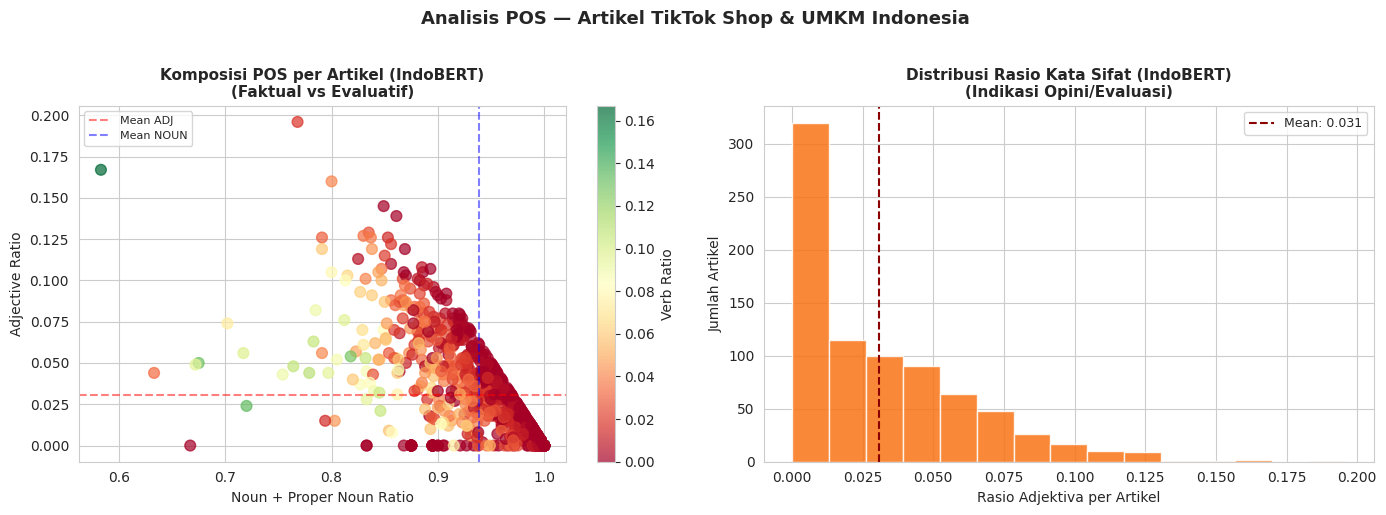

✅ Plot disimpan → /content/figures/pos_per_doc_analysis_indobert.png

📊 Statistik rata-rata rasio POS per dokumen:


,noun_ratio,verb_ratio,adj_ratio,adv_ratio
count,804.000,804.000,804.000,804.000
mean,0.939,0.014,0.031,0.003
std,0.058,0.023,0.031,0.014
min,0.583,0.000,0.000,0.000
25%,0.908,0.000,0.004,0.000
50%,0.951,0.003,0.022,0.000
75%,0.987,0.020,0.048,0.000
max,1.000,0.167,0.196,0.125


In [8]:
# ─── Analisis rasio POS per dokumen ───
# Menggunakan `all_tokens_pos` yang sudah dihasilkan dari proses sebelumnya

per_doc_pos = []
for i, doc_pos_tags in enumerate(all_tokens_pos):
    doc_counter = Counter(doc_pos_tags)
    total = sum(doc_counter.values()) or 1
    per_doc_pos.append({
        "index": i,
        "title": df["title"].iloc[i] if "title" in df.columns else f"Dok-{i}",
        "noun_ratio":  round((doc_counter.get("NNO", 0) + doc_counter.get("NNP", 0)) / total, 3),
        "verb_ratio":  round(doc_counter.get("VBI", 0) / total, 3),
        "adj_ratio":   round(doc_counter.get("ADJ", 0) / total, 3),
        "adv_ratio":   round(doc_counter.get("ADV", 0) / total, 3),
        "total_tokens": total,
    })

pos_per_doc_df = pd.DataFrame(per_doc_pos)
pos_per_doc_df.to_csv("/content/data/pos_per_document_indobert.csv", index=False)
print("✅ Disimpan → /content/data/pos_per_document_indobert.csv")

# Visualisasi distribusi rasio Noun vs Adjective per dokumen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: NOUN ratio vs ADJ ratio
sc = axes[0].scatter(
    pos_per_doc_df["noun_ratio"],
    pos_per_doc_df["adj_ratio"],
    c=pos_per_doc_df["verb_ratio"],
    cmap="RdYlGn", s=60, alpha=0.7
)
plt.colorbar(sc, ax=axes[0], label="Verb Ratio")
axes[0].set_xlabel("Noun + Proper Noun Ratio", fontsize=10)
axes[0].set_ylabel("Adjective Ratio", fontsize=10)
axes[0].set_title("Komposisi POS per Artikel (IndoBERT)\n(Faktual vs Evaluatif)", fontsize=11, fontweight='bold')
axes[0].axhline(y=pos_per_doc_df["adj_ratio"].mean(), color='red', linestyle='--', alpha=0.5, label='Mean ADJ')
axes[0].axvline(x=pos_per_doc_df["noun_ratio"].mean(), color='blue', linestyle='--', alpha=0.5, label='Mean NOUN')
axes[0].legend(fontsize=8)

# Histogram rasio Adjektiva
axes[1].hist(pos_per_doc_df["adj_ratio"], bins=15, color='#f97316', edgecolor='white', alpha=0.85)
axes[1].axvline(x=pos_per_doc_df["adj_ratio"].mean(), color='darkred', linestyle='--',
                label=f"Mean: {pos_per_doc_df['adj_ratio'].mean():.3f}")
axes[1].set_xlabel("Rasio Adjektiva per Artikel", fontsize=10)
axes[1].set_ylabel("Jumlah Artikel", fontsize=10)
axes[1].set_title("Distribusi Rasio Kata Sifat (IndoBERT)\n(Indikasi Opini/Evaluasi)", fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle("Analisis POS — Artikel TikTok Shop & UMKM Indonesia", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("/content/figures/pos_per_doc_analysis_indobert.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Plot disimpan → /content/figures/pos_per_doc_analysis_indobert.png")

# Statistik ringkasan
print("\n📊 Statistik rata-rata rasio POS per dokumen:")
display(pos_per_doc_df[["noun_ratio","verb_ratio","adj_ratio","adv_ratio"]].describe().round(3))

## Cell 6: NER — Distribusi Label Entitas dengan IndoBERT

Sekarang kita akan melakukan Named Entity Recognition menggunakan model `cahya/bert-base-indonesian-NER`. Output dari model ini akan dianalisis untuk mendapatkan distribusi label entitas dan entitas paling dominan per kategori.

⏳ Proses NER dengan IndoBERT...
✅ Disimpan → /content/data/ner_label_counts_indobert.csv
✅ Disimpan → /content/data/ner_top_entities_indobert.json


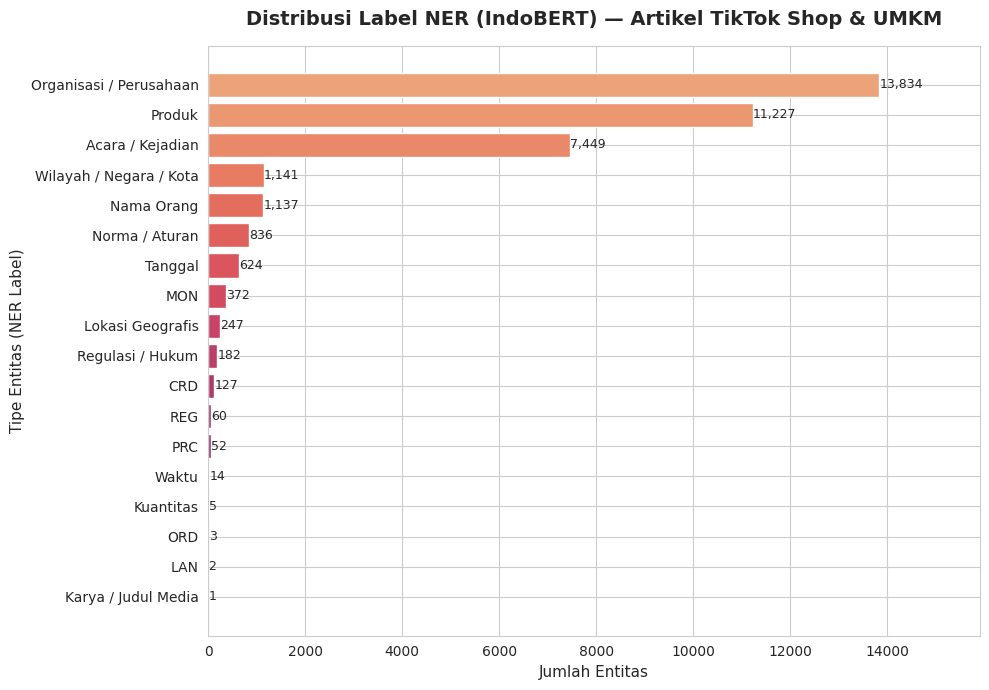

✅ Plot disimpan → /content/figures/ner_label_distribution_indobert.png


,label,label_id,count
0,ORG,Organisasi / Perusahaan,13834
1,PRD,Produk,11227
2,EVT,Acara / Kejadian,7449
3,GPE,Wilayah / Negara / Kota,1141
4,PER,Nama Orang,1137
5,NOR,Norma / Aturan,836
6,DAT,Tanggal,624
7,MON,MON,372
8,LOC,Lokasi Geografis,247
9,LAW,Regulasi / Hukum,182


In [12]:
# --- NER: Agregasi label dan top entitas per label dengan IndoBERT ---

ent_counter = Counter()
per_label   = {}
all_ner_entities = []
all_ner_labels = []

print("⏳ Proses NER dengan IndoBERT...")
batch_size = 8 # Adjust batch size based on GPU memory
max_seq_length = 512 # Max sequence length for the NER model
def safe_truncate(text, max_tokens=500):
    tokens = ner_tokenizer(
        text,
        truncation=True,
        max_length=max_tokens,
        return_tensors=None
    )
    return ner_tokenizer.decode(tokens["input_ids"])

for i in range(0, len(texts), batch_size):
    batch_texts = texts[i:i + batch_size]

    safe_batch = [safe_truncate(t) for t in batch_texts]

    results = ner_pipeline(
        safe_batch,
        batch_size=batch_size
    )
    for doc_result in results:
        doc_entities = []
        doc_labels = []
        for entity in doc_result:
            entity_text = entity['word']
            entity_label = entity['entity_group']

            # ── Filter subword tokens (##xxx) dan token terlalu pendek ──
            clean_text = entity_text.replace("##", "").strip()
            if entity_text.startswith("##") or len(clean_text) < 2:
                continue

            ent_counter[entity_label] += 1
            per_label.setdefault(entity_label, Counter())[entity_text.lower()] += 1
            doc_entities.append((entity_text, entity_label))
            doc_labels.append(entity_label)
        all_ner_entities.append(doc_entities)
        all_ner_labels.append(doc_labels)

ent_df = pd.DataFrame(
    ent_counter.items(), columns=["label", "count"]
).sort_values("count", ascending=False).reset_index(drop=True)

# Simpan distribusi label
ent_df.to_csv("/content/data/ner_label_counts_indobert.csv", index=False)
print("✅ Disimpan → /content/data/ner_label_counts_indobert.csv")

# Simpan top-20 entitas per label ke JSON
top_entities = {label: counter.most_common(20) for label, counter in per_label.items()}
with open("/content/data/ner_top_entities_indobert.json", "w", encoding="utf-8") as f:
    json.dump(top_entities, f, ensure_ascii=False, indent=2)
print("✅ Disimpan → /content/data/ner_top_entities_indobert.json")

# --- Peta label NER ke penjelasan kontekstual (disesuaikan dengan output aktual IndoBERT NER) ---
# Model cahya/bert-base-indonesian-NER menghasilkan label: ORG, PER, LOC, DAT, TIM, PRD, EVT, GPE, LAW
ner_labels_hf = {
    "PER":     "Nama Orang",
    "ORG":     "Organisasi / Perusahaan",
    "LOC":     "Lokasi Geografis",
    "TIM":     "Waktu",
    "DAT":     "Tanggal",
    "TTL":     "Judul",
    "EVT":     "Acara / Kejadian",
    "PRD":     "Produk",          # label aktual model: PRD (bukan PRO)
    "PRO":     "Produk",          # fallback jika muncul PRO
    "FIN":     "Keuangan",
    "IND":     "Industri",
    "MONEY":   "Nominal Uang",
    "GPE":     "Wilayah / Negara / Kota",
    "LAW":     "Regulasi / Hukum",   # label aktual model: LAW
    "MISC":    "Lain-lain",
    "NOR":     "Norma / Aturan",
    "QTY":     "Kuantitas",
    "WOA":     "Karya / Judul Media",
}
ent_df["label_id"] = ent_df["label"].map(ner_labels_hf).fillna(ent_df["label"])

# --- Visualisasi distribusi label NER ---
palette = sns.color_palette("flare", n_colors=len(ent_df))
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(ent_df["label_id"], ent_df["count"], color=palette)
for bar, val in zip(bars, ent_df["count"]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title("Distribusi Label NER (IndoBERT) — Artikel TikTok Shop & UMKM", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Jumlah Entitas", fontsize=11)
ax.set_ylabel("Tipe Entitas (NER Label)", fontsize=11)
ax.invert_yaxis()
# Tambah margin kanan agar angka tidak terpotong
xmax = ent_df["count"].max()
ax.set_xlim(0, xmax * 1.15)
plt.tight_layout()
plt.savefig("/content/figures/ner_label_distribution_indobert.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Plot disimpan → /content/figures/ner_label_distribution_indobert.png")

display(ent_df[["label", "label_id", "count"]])


## Cell 7: NER — Top Entitas per Label dengan IndoBERT (Relevan dengan Konteks UMKM)

Visualisasi entitas teratas per label untuk memahami entitas kunci yang muncul dalam teks, sekarang menggunakan hasil dari model IndoBERT NER.

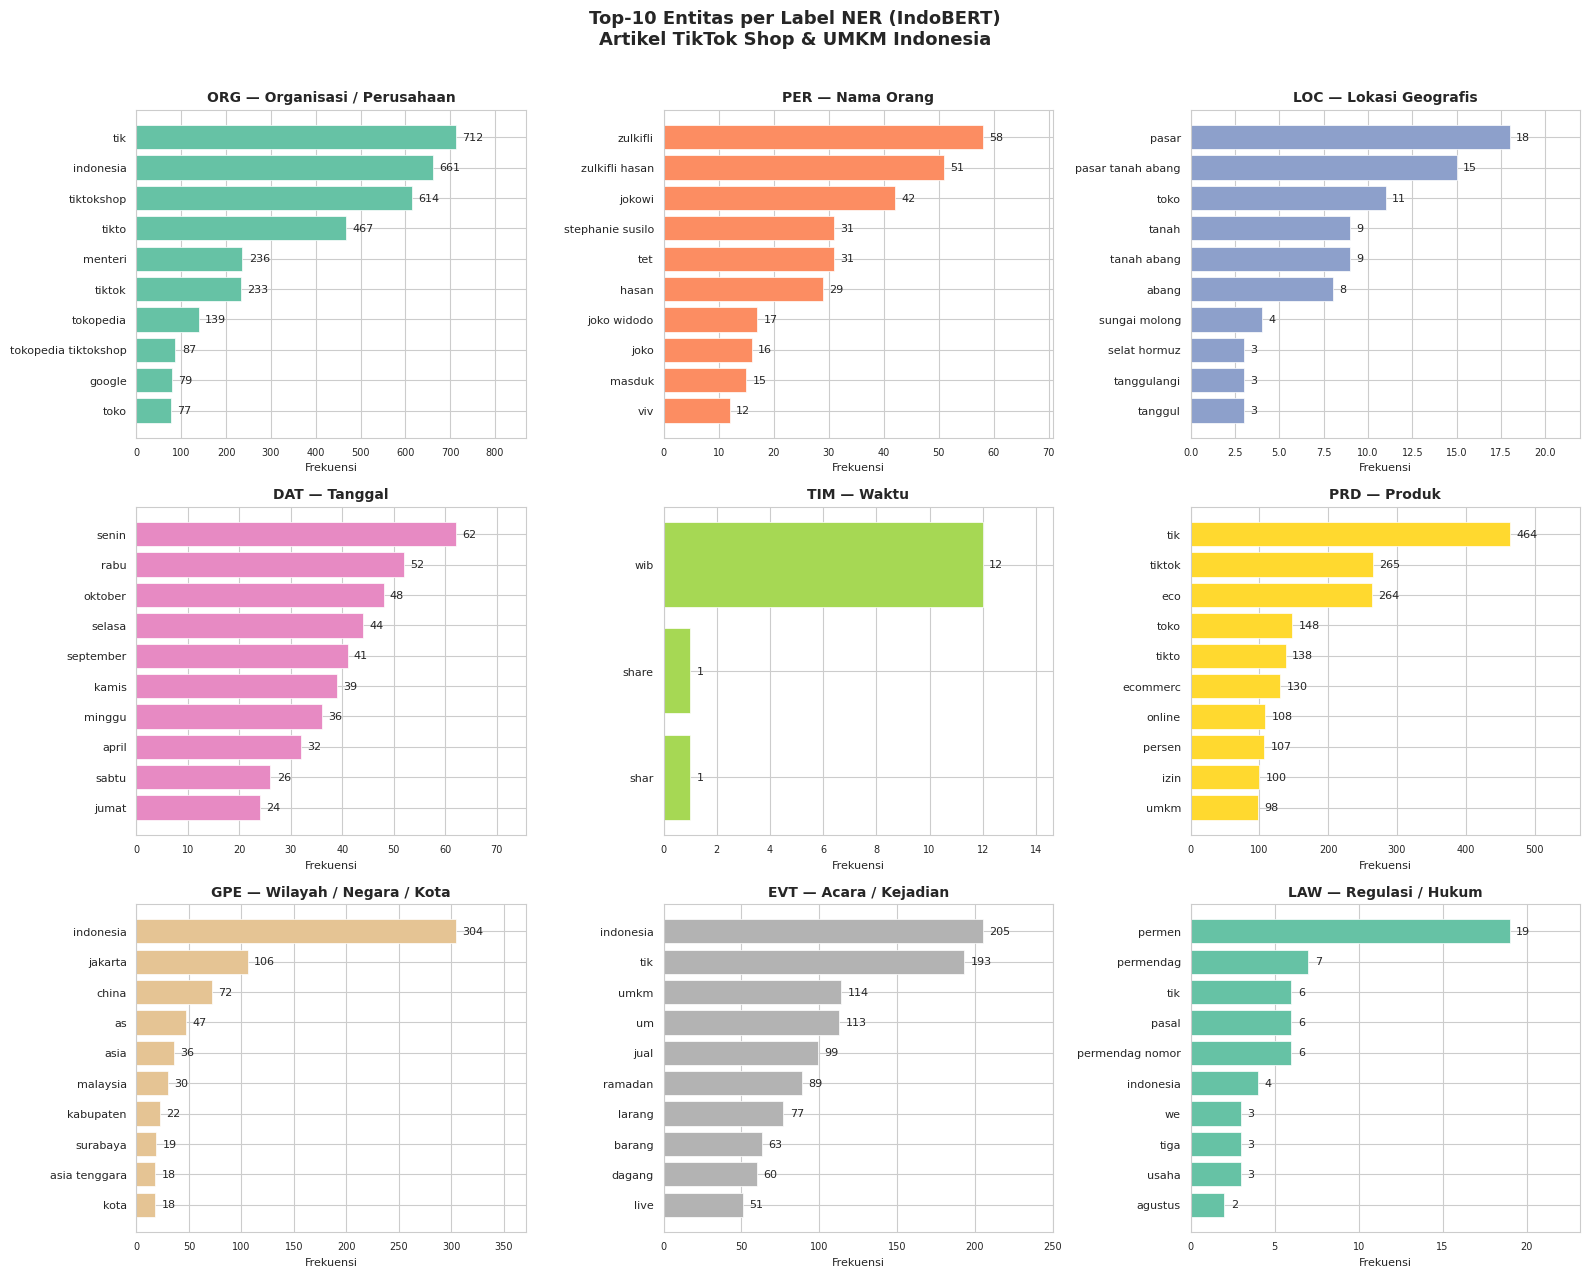

✅ Plot disimpan → /content/figures/ner_top_entities_per_label_indobert.png


In [13]:
# ─── Top-10 entitas per label (bar chart grid) dengan IndoBERT ───

# ── Pre-processing: bersihkan subword dari per_label (jaga-jaga jika sudah tersimpan) ──
per_label_clean = {}
for lbl, counter in per_label.items():
    clean_counter = Counter()
    for word, freq in counter.items():
        if not word.startswith("##") and len(word.replace("##", "").strip()) >= 2:
            clean_counter[word] += freq
    if clean_counter:
        per_label_clean[lbl] = clean_counter

# Label prioritas disesuaikan dengan output aktual model cahya/bert-base-indonesian-NER
priority_labels = ["ORG", "PER", "LOC", "DAT", "TIM", "PRD", "GPE", "EVT", "LAW"]
available_labels = [l for l in priority_labels if l in per_label_clean and len(per_label_clean[l]) > 0]

# Tambahkan label lain yang ada di data tapi tidak di priority
other_labels = [l for l in per_label_clean if l not in priority_labels and len(per_label_clean[l]) > 0]
plot_labels = (available_labels + other_labels)[:9]  # max 9 subplot

if not plot_labels:
    print("⚠️ Tidak ada entitas yang terdeteksi dengan model IndoBERT NER.")
else:
    n = len(plot_labels)
    cols = 3
    rows = (n + cols - 1) // cols

    # Palet warna berbeda per subplot agar mudah dibedakan
    subplot_colors = sns.color_palette("Set2", n_colors=max(n, 9))

    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4.2))
    axes = axes.flatten() if n > 1 else [axes]

    for idx, (ax, label) in enumerate(zip(axes, plot_labels)):
        top = per_label_clean[label].most_common(10)
        if not top:
            ax.axis('off')
            continue

        entities, freqs = zip(*top)
        ent_list  = list(entities)[::-1]
        freq_list = list(freqs)[::-1]

        color = subplot_colors[idx % len(subplot_colors)]
        bars = ax.barh(ent_list, freq_list, color=color, edgecolor='white', linewidth=0.5)

        # Tambah margin kanan agar label angka tidak terpotong
        xmax = max(freq_list)
        ax.set_xlim(0, xmax * 1.22)

        for bar, val in zip(bars, freq_list):
            ax.text(bar.get_width() + xmax * 0.02,
                    bar.get_y() + bar.get_height() / 2,
                    str(val), va='center', fontsize=8)

        # Gunakan ner_labels_hf yang sudah diperbaiki
        label_name = ner_labels_hf.get(label, label)
        ax.set_title(f"{label} — {label_name}", fontsize=10, fontweight='bold')
        ax.set_xlabel("Frekuensi", fontsize=8)
        ax.tick_params(axis='y', labelsize=8)
        ax.tick_params(axis='x', labelsize=7)

    # Sembunyikan subplot kosong
    for ax in axes[n:]:
        ax.axis('off')

    plt.suptitle("Top-10 Entitas per Label NER (IndoBERT)\nArtikel TikTok Shop & UMKM Indonesia",
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig("/content/figures/ner_top_entities_per_label_indobert.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Plot disimpan → /content/figures/ner_top_entities_per_label_indobert.png")


## Cell 8: NER — Visualisasi Highlight Entitas (Sample Artikel) dengan IndoBERT

 kami akan membuat fungsi visualisasi kustom sederhana untuk menyoroti entitas yang terdeteksi oleh model IndoBERT NER dalam beberapa contoh artikel. Ini akan membantu memverifikasi kualitas deteksi entitas.

In [14]:
# ─── Visualisasi kustom untuk NER IndoBERT ───

# Warna kustom per entitas - disesuaikan dengan konteks UMKM Indonesia dan label IndoBERT NER
ner_colors_html = {
    "ORG":     "#ffd966",   # Organisasi/Perusahaan → kuning
    "PER":     "#fca5a5",   # Nama Orang → merah muda
    "LOC":     "#a7f3d0",   # Lokasi Geografis → hijau
    "DAT":     "#93c5fd",   # Tanggal → biru
    "TIM":     "#c7d2fe",   # Waktu → ungu muda
    "PRO":     "#f9a8d4",   # Produk → pink
    "EVT":     "#fbbf24",   # Acara / Kejadian → oranye
    "FIN":     "#fcd34d",   # Keuangan → kuning tua
    "IND":     "#86efac",  # Industri → hijau muda
    "TTL":     "#d8b4fe",   # Judul → lavender
    "MISC":    "#e5e7eb",   # Lain-lain → abu-abu
}

def highlight_entities(text, entities, colors):
    # Sort entities by start index to handle overlaps correctly
    entities.sort(key=lambda x: x['start'])

    result = []
    last_end = 0
    for ent in entities:
        start = ent['start']
        end = ent['end']
        label = ent['entity_group'] # Corrected: Use 'entity_group' for NER labels
        word = ent['word']

        # Add text before the current entity
        result.append(text[last_end:start])

        # Add the highlighted entity
        color = colors.get(label, "#e5e7eb") # Default grey for unknown labels
        result.append(f'<mark class="entity" style="background: {color}; padding: 0.45em 0.6em; margin: 0 0.25em; line-height: 1; border-radius: 0.35em;">'
                      f'{word} <span style="font-size: 0.8em; font-weight: bold; line-height: 1; border-radius: 0.35em; text-transform: uppercase; vertical-align: middle; margin-left: 0.5rem;">{label}</span>'
                      f'</mark>')
        last_end = end

    # Add any remaining text after the last entity
    result.append(text[last_end:])
    return ''.join(result)

# ─── Tampilkan 3 contoh artikel dengan entitas ───
n_examples = 3
shown = 0

# Gunakan teks asli (content_cleaned) agar lebih terbaca
raw_col = "content_cleaned" if "content_cleaned" in df.columns else "text_for_nlp"
raw_texts = df[raw_col].fillna("").astype(str).tolist()

print("⏳ Menghasilkan visualisasi NER kustom...")
html_output = []
for i, text in enumerate(raw_texts):
    # Batasi teks agar tidak terlalu panjang untuk visualisasi
    truncated_text = text[:1000]
    entities = ner_pipeline(truncated_text)

    if len(entities) > 2: # Hanya tampilkan jika ada entitas yang cukup
        title = df["title"].iloc[i] if "title" in df.columns else f"Artikel-{i}"
        html_output.append(f"<h3>Sample {shown+1}: {title[:80]}</h3>")
        html_output.append(f"<p>Entitas ditemukan: {len(entities)}</p>")
        html_output.append(f"<div>{highlight_entities(truncated_text, entities, ner_colors_html)}</div>")
        html_output.append("<hr/>")
        shown += 1
    if shown >= n_examples:
        break

if html_output:
    from IPython.display import HTML
    display(HTML(''.join(html_output)))

    # Simpan satu contoh ke HTML untuk laporan
    sample_doc_entities = ner_pipeline(raw_texts[0][:1000])
    sample_html = f"<html><head><title>NER Sample</title></head><body><h1>NER Sample (IndoBERT)</h1>{highlight_entities(raw_texts[0][:1000], sample_doc_entities, ner_colors_html)}</body></html>"
    with open("/content/figures/ner_sample_indobert.html", "w", encoding="utf-8") as f:
        f.write(sample_html)
    print("\n💾 File HTML disimpan → /content/figures/ner_sample_indobert.html")
    print("📥 Download: panel kiri > figures > ner_sample_indobert.html > Download")
else:
    print("❌ Tidak ada dokumen dengan entitas yang cukup untuk ditampilkan.")

⏳ Menghasilkan visualisasi NER kustom...



💾 File HTML disimpan → /content/figures/ner_sample_indobert.html
📥 Download: panel kiri > figures > ner_sample_indobert.html > Download


## Cell 9: Integrasi — POS & NER IndoBERT ke DataFrame Utama

Kami akan mengintegrasikan hasil POS tagging dan NER dari model IndoBERT ke dalam DataFrame utama. Ini akan memungkinkan analisis lebih lanjut berdasarkan data yang kaya entitas.

In [15]:
# ─── Tambahkan kolom POS & NER (IndoBERT) ke DataFrame utama ───

df["pos_tags_indobert"]       = all_tokens_pos
df["ner_entities_indobert"]   = all_ner_entities
df["ner_labels_indobert"]     = all_ner_labels
df["ner_count_indobert"]      = df["ner_entities_indobert"].apply(len)
df["has_org_indobert"]        = df["ner_labels_indobert"].apply(lambda x: "ORG" in x)
# Adjust for common IndoBERT NER labels
df["has_law_indobert"]        = df["ner_labels_indobert"].apply(lambda x: "LAW" in x or "REG" in x) # Assuming 'LAW' or similar label
df["has_money_indobert"]      = df["ner_labels_indobert"].apply(lambda x: "FIN" in x or "MONEY" in x)

# Simpan dataset dengan POS & NER IndoBERT
output_path_indobert = "/content/scraped_articles_pos_ner_indobert.csv"
df_save_indobert = df.copy()
# Konversi list ke string agar bisa disimpan CSV
df_save_indobert["pos_tags_indobert"]     = df_save_indobert["pos_tags_indobert"].apply(str)
df_save_indobert["ner_entities_indobert"] = df_save_indobert["ner_entities_indobert"].apply(str)
df_save_indobert["ner_labels_indobert"]   = df_save_indobert["ner_labels_indobert"].apply(str)
df_save_indobert.to_csv(output_path_indobert, index=False)
print(f"Dataset dengan POS & NER IndoBERT disimpan → {output_path_indobert}")

# Ringkasan
print(f"\n📊 Ringkasan NER IndoBERT:")
print(f"   Artikel dengan entitas ORG  : {df['has_org_indobert'].sum()} / {len(df)}")
print(f"   Artikel dengan entitas LAW  : {df['has_law_indobert'].sum()} / {len(df)}")
print(f"   Artikel dengan entitas MONEY: {df['has_money_indobert'].sum()} / {len(df)}")
print(f"   Rata-rata entitas per artikel: {df['ner_count_indobert'].mean():.2f}")

display(df[["title", "ner_count_indobert", "has_org_indobert", "has_law_indobert", "has_money_indobert"]].head(10))

Dataset dengan POS & NER IndoBERT disimpan → /content/scraped_articles_pos_ner_indobert.csv

📊 Ringkasan NER IndoBERT:
   Artikel dengan entitas ORG  : 735 / 804
   Artikel dengan entitas LAW  : 110 / 804
   Artikel dengan entitas MONEY: 0 / 804
   Rata-rata entitas per artikel: 46.41


,title,ner_count_indobert,has_org_indobert,has_law_indobert,has_money_indobert
0,TikTok raises minimum user age in Indonesia fo...,58,True,True,False
1,TikTok Indonesia Resmi Umumkan Tutup Fitur Tik...,103,True,False,False
2,LIVE Tokopedia–TikTok Shop Ditonton 38 Miliar ...,52,True,False,False
3,Konten Jadi Mesin Penggerak Penjualan di Tokop...,73,True,False,False
4,usmile Indonesia Berhasil Dominasi Kategori Pr...,44,True,True,False
5,Indonesia Menjadi Pasar Terbesar Kedua bagi Ti...,82,True,False,False
6,Strategi Konten Dongkrak Penjualan di Tokopedi...,28,True,False,False
7,Usmile Indonesia Jadi Top ‘Premium’ Oral Care ...,84,True,False,False
8,Belanja Online di Indonesia Hampir Rp1.000 Tri...,17,True,False,False
9,Transaksi Tokopedia dan TikTok Shop Melonjak 1...,4,False,False,False


## Cell 10: Ringkasan & Interpretasi Temuan IndoBERT

In [16]:
# ─── Ringkasan temuan POS & NER (IndoBERT) ───
print("=" * 65)
print("  RINGKASAN HASIL POS & NER (IndoBERT) — TikTok Shop & UMKM Indonesia")
print("=" * 65)

print("\n POS TAGGING (IndoBERT):")
if len(pos_df) > 0:
    top3_pos = pos_df.head(3)
    for _, row in top3_pos.iterrows():
        print(f"   • {row['label_id']}: {row['count']:,} token")

    # Sum of counts might be slightly different for HuggingFace due to tokenization differences
    total_pos_tokens = sum(pos_counts.values())
    noun_ratio = pos_counts.get("NOUN", 0) / max(total_pos_tokens, 1)
    adj_ratio  = pos_counts.get("ADJ", 0) / max(total_pos_tokens, 1)
    print(f"   → Rasio Nomina: {noun_ratio:.1%} | Rasio Adjektiva: {adj_ratio:.1%}")
    print(f"   → Teks cenderung {'FAKTUAL (informatif)' if noun_ratio > 0.3 else 'EVALUATIF (opini)'}")

print("\n NAMED ENTITY RECOGNITION (IndoBERT):")
if len(ent_df) > 0:
    top3_ner = ent_df.head(3)
    for _, row in top3_ner.iterrows():
        print(f"   • {row['label_id']}: {row['count']:,} entitas")

print("\n TOP ENTITAS KUNCI (konteks TikTok Shop & UMKM, IndoBERT):")
for label in ["ORG", "PER", "LOC", "DAT", "PRO", "FIN"]:
    if label in per_label:
        top5 = [e for e, _ in per_label[label].most_common(5)]
        print(f"   [{ner_labels_hf.get(label, label)}]: {', '.join(top5)}")

print("\n FILE OUTPUT BARU (IndoBERT):")
files_indobert = [
    "/content/data/pos_distribution_indobert.csv",
    "/content/data/pos_per_document_indobert.csv",
    "/content/data/ner_label_counts_indobert.csv",
    "/content/data/ner_top_entities_indobert.json",
    "/content/figures/pos_distribution_indobert.png",
    "/content/figures/pos_per_doc_analysis_indobert.png",
    "/content/figures/ner_label_distribution_indobert.png",
    "/content/figures/ner_top_entities_per_label_indobert.png",
    "/content/figures/ner_sample_indobert.html",
    "/content/scraped_articles_pos_ner_indobert.csv",
]
for f in files_indobert:
    status = "✅" if os.path.exists(f) else "❌"
    print(f"   {status} {f}")

  RINGKASAN HASIL POS & NER (IndoBERT) — TikTok Shop & UMKM Indonesia

 POS TAGGING (IndoBERT):
   • NNP: 105,729 token
   • NNO: 67,996 token
   • Adjektiva (Kata Sifat): 5,842 token
   → Rasio Nomina: 0.0% | Rasio Adjektiva: 3.2%
   → Teks cenderung EVALUATIF (opini)

 NAMED ENTITY RECOGNITION (IndoBERT):
   • Organisasi / Perusahaan: 13,834 entitas
   • Produk: 11,227 entitas
   • Acara / Kejadian: 7,449 entitas

 TOP ENTITAS KUNCI (konteks TikTok Shop & UMKM, IndoBERT):
   [Organisasi / Perusahaan]: tik, indonesia, tiktokshop, tikto, menteri
   [Nama Orang]: zulkifli, zulkifli hasan, jokowi, stephanie susilo, tet
   [Lokasi Geografis]: pasar, pasar tanah abang, toko, tanah, tanah abang
   [Tanggal]: senin, rabu, oktober, selasa, september

 FILE OUTPUT BARU (IndoBERT):
   ✅ /content/data/pos_distribution_indobert.csv
   ✅ /content/data/pos_per_document_indobert.csv
   ✅ /content/data/ner_label_counts_indobert.csv
   ✅ /content/data/ner_top_entities_indobert.json
   ✅ /content/figur